# Chebyshev center of a polyhedron

Consider the problem of finding the largest Euclidean ball that lies inside a polyhedron
		$$P = \{x \in \mathbb{R}^n \mid a_i^T x \le b_i, i=1,\ldots,m\}. $$
        
In the lecture, we showed that it can be modelled by the following LP:

$$
\begin{array}{}
\text{maximize}  & r &\\
\text{subject to}& a_i^Tx_c+r\|a_i\|_2 \le b_i & \text{for $i=1,\ldots,m$}
\end{array}
$$

Code this model in Gurobi. Your code should work for any dimension $n$. Then test it in 2D so that it finds the center of a polygon given by a list of vertices. Experiment with a few different polygons.

In [1]:
from gurobipy import Model, GRB

vertices = [(0,0), (2,0), (2/3,2+2/3), (-4/3, 2/3)]

# ... code and solve the model using Gurobi

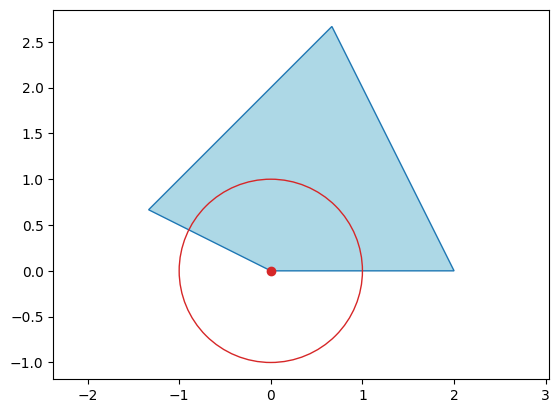

In [2]:
import matplotlib.pyplot as plt
xs, ys = zip(*(vertices + [vertices[0]])) #create lists of x and y values

plt.figure()
plt.axis('equal')
plt.fill(xs,ys,facecolor='lightblue', edgecolor='tab:blue', linewidth=1) 
cir=plt.Circle((0, 0), 1, fill=False, edgecolor='tab:red')
plt.gca().add_patch(cir)
plt.plot(0, 0, 'o', color='tab:red')
plt.show()

In [3]:
cheb_m = Model("chebyshev_center")

Restricted license - for non-production use only - expires 2027-11-29


In [4]:
n = len(vertices[0]) # dimension of the space

# last variable denotes the radius of the inscribed ball
x = cheb_m.addMVar(shape=n+1, name="x")

In [5]:
x

<MVar (3,)>
array([<gurobi.Var *Awaiting Model Update*>,
       <gurobi.Var *Awaiting Model Update*>,
       <gurobi.Var *Awaiting Model Update*>])

In [6]:
normals = []
bs = []
for i in range(len(vertices)):
    a = vertices[i]
    b = vertices[(i+1) % len(vertices)]
    # compute the normal vector to the edge (a,b)
    normals.append((b[1] - a[1], a[0] - b[0]))
    bs.append(normals[-1][0]*a[0] + normals[-1][1]*a[1])

In [ ]:
# A general algorithm that works with vertices would be complicated - we were told that we shouldn't do that.
# Instead, we generate an algorithm that generalises to higher dimensions assuming normals and bs are given.

# define matrix A with normals + ||normals||_2 in rows and vector b with bs
A = []
for i in range(len(normals)):
    A.append(list(normals[i]) + [((normals[i][0]**2 + normals[i][1]**2)**0.5)])
b = bs

# convert A and b to numpy arrays
import numpy as np
A = np.array(A)
b = np.array(b)


In [8]:
A

array([[ 0.        , -2.        ,  2.        ],
       [ 2.66666667,  1.33333333,  2.98142397],
       [-2.        ,  2.        ,  2.82842712],
       [-0.66666667, -1.33333333,  1.49071198]])

In [9]:
b

array([0.        , 5.33333333, 4.        , 0.        ])

In [10]:
# add objective
obj = np.array([0, 0, 1]) # maximize the radius of the inscribed ball
cheb_m.setObjective(obj @ x, GRB.MAXIMIZE)

In [11]:
# add constraints in the matrix form
cheb_m.addConstr(A @ x <= b, name='c')

<MConstr (4,) *awaiting model update*>

In [12]:
cheb_m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4 Pro
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 4 rows, 3 columns and 11 nonzeros (Max)
Model fingerprint: 0x1b52c5a6
Model has 1 linear objective coefficients
Coefficient statistics:
  Matrix range     [7e-01, 3e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 5e+00]

Presolve removed 1 rows and 0 columns
Presolve time: 0.00s
Presolved: 3 rows, 3 columns, 9 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.2360680e+00   4.405637e-01   0.000000e+00      0s
       3    9.9200259e-01   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.00 seconds (0.00 work units)
Optimal objective  9.920025865e-01


In [13]:
x

<MVar (3,)>
array([<gurobi.Var x[0] (value 0.3949060981642667)>,
       <gurobi.Var x[1] (value 0.9920025864696703)>,
       <gurobi.Var x[2] (value 0.9920025864696703)>])

In [14]:
center = x.X[:2]
radius = x.X[2]

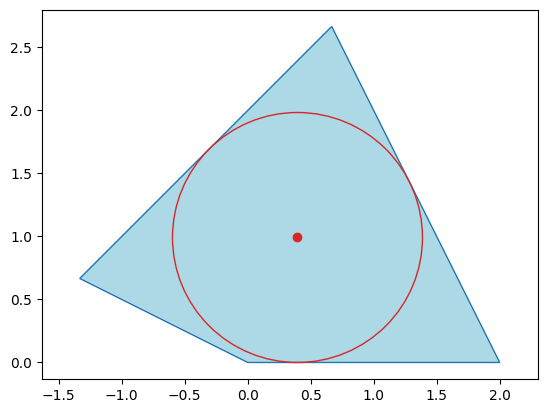

In [15]:
plt.figure()
plt.axis('equal')
plt.fill(xs,ys,facecolor='lightblue', edgecolor='tab:blue', linewidth=1) 
cir=plt.Circle((center[0], center[1]), radius, fill=False, edgecolor='tab:red')
plt.gca().add_patch(cir)
plt.plot(center[0], center[1], 'o', color='tab:red')
plt.show()